In [1]:
%cd ../.
import os, sys
sys.path.insert(0, os.path.abspath('../Scripts'))
sys.path.insert(0, os.path.expanduser('~/CDD_Vault_API/python'))  # CDD Vault API (get_df)

/home/gtamo/MS_ML


In [2]:
%load_ext autoreload
%autoreload 2

import re
import os
import tempfile
import pandas as pd
import numpy as np
import py3Dmol
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import csv
import pickle

from pathlib import Path
from rdkit import Chem
from rdkit.Chem import AllChem,rdFMCS
# import prolif as plf
from glob import glob
import meeko
import subprocess as sub
# from vina import Vina
import time
from tqdm.auto import tqdm  # auto -> notebook/VSCode widget
tqdm.pandas()
import importlib
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, silhouette_score, davies_bouldin_score, calinski_harabasz_score
from xgboost import XGBClassifier,XGBRegressor
from openTSNE import TSNE as oTSNE        # pip install openTSNE
import seaborn as sns
from scipy import stats
import pyarrow.dataset as pads
import csv, contextlib, threading, joblib
import joblib
from joblib import Parallel, delayed
from datetime import date

# user defined modules
import Rdkit_tools as rdkit_tools
importlib.reload(rdkit_tools)
import Molecule as M
import ML_Reg as ML_Reg
import ML_Class as ML_Class
from MolViz3D import MolViz3D
import Statistics_tools as stats_tools
import python.functions as fn
from get_library import get_df   # CDD Vault collection export
from mltrail import Registry
# from tdc.multi_pred import DTI

/home/gtamo/miniconda3/envs/ML/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


> could not load openbabel


In [22]:
# -------------------
# CONFIG Params
# -------------------

import yaml
from types import SimpleNamespace
with open('config/config.yaml') as _f:
    _cfg = yaml.safe_load(_f)
config = SimpleNamespace(**_cfg)
globals().update(_cfg)
print(f'> loaded {len(_cfg)} params from config/config.yaml')

# -------------------
# Dropbox access — stream files over the ssh tunnel when DROPBOX_SSH_HOST is set
# (see wiki "Dropbox access"; the reverse tunnel must be up), else read local paths.
# -------------------

os.environ.setdefault('DROPBOX_SSH_HOST', DROPBOX_SSH_HOST)
os.environ.setdefault('DROPBOX_SSH_PORT', str(DROPBOX_SSH_PORT))
_use_ssh  = bool(DROPBOX_SSH_HOST)
_dbx      = fn.open_dropbox if _use_ssh else (lambda p: p)   # wrap Dropbox paths; local data/ paths stay bare
_fbx_open = fn.open_dropbox if _use_ssh else None
_fbx_glob = fn.glob_dropbox if _use_ssh else None

# -------------------
# MLTrail Params
# -------------------

registry = Registry.from_default()   # shared vault from MLTrail config; reuse for every add/predict


> loaded 51 params from config/config.yaml


## 0. Imports

In [4]:
%%time
## latest library straight from CDD Vault (collections AJ/AK), compound name + smiles only
if CHEMLIB_OVERWRITE:
    serac_df = (get_df(vault=7108, collections=['AK', 'AJ'], columns=['name','Batch Mol-Batch ID', 'smiles','Px_repetition(yes/no)','Px_validated_WT(yes/no)','Px_Ligase_dependent(yes/no)',
                                                                      'Px_NameLigase_dependent','Px_Target_info','Px_Target_interest' ])
                .rename(columns={'name': 'compound'}))
    serac_df.to_csv(CHEMLIB_PATH,sep=',',index=False)
else:
    serac_df = pd.read_csv(CHEMLIB_PATH)
serac_df = serac_df.drop_duplicates()
serac_df['Px_validated_WT(yes/no)'] = serac_df['Px_validated_WT(yes/no)'].astype('string').str.strip().str.lower().map({'yes': 1, 'no': 0})  # ['', 'yes', 'no'] -> [NaN, 1, 0]
serac_df['Px_Ligase_dependent(yes/no)'] = serac_df['Px_Ligase_dependent(yes/no)'].astype('string').str.strip().str.lower().map({'yes': 1, 'no': 0})  # ['', 'yes', 'no'] -> [NaN, 1, 0]
serac_df['Px_repetition(yes/no)'] = serac_df['Px_repetition(yes/no)'].astype('string').str.strip().str.lower().map({'yes': 1, 'no': 0})  # ['', 'yes', 'no'] -> [NaN, 1, 0]

## extract list of validated and devalidated targets
l1 = list(set(serac_df[(serac_df['Px_Ligase_dependent(yes/no)']==0) & 
                       (serac_df['Px_Target_interest'].notnull())]['Px_Target_interest']))
devalidated_targets = list(set([s.split(' ')[0].upper() for x in l1 for s in x.split(';')]))

l2 = list(set(serac_df[(serac_df['Px_Ligase_dependent(yes/no)']==1) & 
                       (serac_df['Px_Target_interest'].notnull())]['Px_Target_interest']))
validated_targets = list(set([s.split(' ')[0].upper() for x in l2 for s in x.split(';')]))

serac_df.shape

CPU times: user 61 ms, sys: 10.9 ms, total: 71.8 ms
Wall time: 70.5 ms


(10058, 9)

In [5]:
## local params — controls + contaminants come from config/config.yaml (CONTROLS / CONTAMINANTS)
control_compounds = list(CONTROLS)                                  # YAML list of control SRB ids
contaminants      = list(pd.read_csv(CONTAMINANTS)['Molecule Name'])  # contaminant compounds to remove
fbx_independent   = list(serac_df[ (serac_df['Px_Ligase_dependent(yes/no)']==0) | (serac_df['Px_validated_WT(yes/no)']==0) ]['compound'].unique()) 
cm2rm             = fbx_independent + control_compounds + contaminants

print(f'> {len(control_compounds)} control + {len(contaminants):,} contaminant compounds (from config) + {len(fbx_independent)} fbx independent = {len(cm2rm)}')

> 2 control + 81 contaminant compounds (from config) + 538 fbx independent = 621


In [6]:
if DFRAW_OVERWRITE:
# if 1<3:
    # -------------------
    # Old data
    # -------------------

    ## Px part 1
    df_raw_20260429, MS20260429 = fn.load_proteomics_data(
        RAW_PROTEOMICS_PATH,
        CLEAN_PROTEOMICS_PATH,
        drop_plates=['Plate12', 'Plate15', 'Plate23'],
    )

    ## Px part 2:
    df_raw_20260520, MS20260520 = fn.load_proteomics_data(
        _dbx(PX_20260520_DB),            # raw per-gene table (Database export) — was wrongly CDDVault
        _dbx(PX_20260520_CDDVAULT),      # metadata table (Vault export: SMILES, Collections)
        drop_plates=['Plate12', 'Plate15', 'Plate23'],
        mode='cddvault',           # Collections recipe (drops PROTACs), join on 'Batch Molecule-Batch ID'
        collections=['AJ', 'AK'],
    )

    ## Px part 3:
    df_raw_20260529, MS20260529 = fn.load_proteomics_data(
        _dbx(PX_20260529_DB),            # raw per-gene table (Database export) — was wrongly CDDVault
        _dbx(PX_20260529_CDDVAULT),      # metadata table (Vault export: SMILES, Collections)
        drop_plates=['Plate12', 'Plate15', 'Plate23'],
        mode='cddvault',           # Collections recipe (drops PROTACs), join on 'Batch Molecule-Batch ID'
        collections=['AJ', 'AK'],
    )
    # manual formatting for 20260529 metadata:
    MS20260529 = MS20260529.rename(columns={'Molecule-Batch ID':'Batch Molecule-Batch ID','Nr. Down':'MSData - Proteomics activities: Nr. Down',"Cmpd Activity" : "MSData - Proteomics activities: Cmpd Activity"})
    parts = MS20260529['Batch Molecule-Batch ID'].str.split('-', n=2, expand=True)
    MS20260529['Molecule Name'] = parts[0] + '-' + parts[1]   # 'SRB-0000385'
    MS20260529['batch']    = parts[2]                    # '001'

    ## Making final df_raw — tag each tranche with its date for the filter below
    df_raw = pd.concat([
        df_raw_20260429.assign(date=pd.to_datetime('20260429')),
        df_raw_20260520.assign(date=pd.to_datetime('20260520')),
        df_raw_20260529.assign(date=pd.to_datetime('20260529')),
    ]).reset_index(drop=True)
    # Per compound: keep the latest batch, then the latest date for repeats
    df_raw = fn.keep_latest_batch_per_compound(df_raw)
    df_raw[['genes']].drop_duplicates().to_csv('data/MS/Px_genes.csv')

    ## check whether all compounds are including in the df_raw:
    colskeep = ['Molecule Name','MSData - Proteomics activities: Nr. Down','origin',"MSData - Proteomics activities: Cmpd Activity"]
    MS = pd.concat([MS20260429.assign(origin='MS20260429'),
                    MS20260520.assign(origin='MS20260520'),
                    MS20260529.assign(origin='MS20260529')]).reset_index(drop=True)[colskeep].rename(columns={'Molecule Name':'compound',
                                                                                                            'MSData - Proteomics activities: Nr. Down':'ndown',
                                                                                                            "MSData - Proteomics activities: Cmpd Activity":'activity'})
    MS['date'] = pd.to_datetime(MS['origin'].str.replace('MS', ''))

    del df_raw_20260429,df_raw_20260520,df_raw_20260529

    # -------------------
    # New (FBX) data
    # -------------------

    # every tranche folder under FBX_DIR (config.yaml), named by export date
    TRANCHES = sorted(fn.glob_dropbox(FBX_DIR, '[0-9]*') if _use_ssh
                      else glob(os.path.join(FBX_DIR, '[0-9]*')))
    _fbx = {os.path.basename(t): fn.load_fbx_tranche(t, control_compounds=control_compounds,
                                                    contaminants=contaminants,
                                                    opener=_fbx_open, lister=_fbx_glob) for t in TRANCHES}

    # stack tranches; on a recurring experiment (uniquecontrast) / compound, keep the LATEST export
    df_raw_fbx = (pd.concat([d.assign(_tranche=k) for k, (d, _) in _fbx.items()], ignore_index=True)
                .sort_values('_tranche').drop_duplicates(['uniquecontrast', 'pg'], keep='last'))  # row key is (contrast, protein); deduping on contrast alone collapsed the proteome
    # stamp each FBX row with its tranche date (folder YYYYMMDD) — FBX_DFRAW_COLS carries no 'date',
    # so without this keep_latest_batch_per_compound sees NaT and drops every FBX row (NaT==NaT is False).
    df_raw_fbx['date'] = pd.to_datetime(df_raw_fbx['_tranche'].str[:8], format='%Y%m%d')
    df_raw_fbx = df_raw_fbx[fn.FBX_DFRAW_COLS + ['date']].reset_index(drop=True)
    MS_fbx = (pd.concat([m for _, m in _fbx.values()], ignore_index=True)
            .sort_values('date').drop_duplicates('compound', keep='last')
            [fn.FBX_MS_COLS].reset_index(drop=True))

    # align to the LIVE df_raw / MS schemas so a plain concat works regardless of any extra
    # columns the in-memory frames carry (e.g. smiles); columns FBX can't fill become NaN.
    _miss_dr = [c for c in df_raw.columns if c not in df_raw_fbx.columns]
    _miss_ms = [c for c in MS.columns     if c not in MS_fbx.columns]
    df_raw_fbx = df_raw_fbx.reindex(columns=df_raw.columns)
    MS_fbx     = MS_fbx.reindex(columns=MS.columns)
    print(f'\n> FBX formatted: df_raw_fbx {df_raw_fbx.shape} | MS_fbx {MS_fbx.shape}')
    print(f'  df_raw schema : {list(df_raw.columns)}')
    print(f'  MS schema     : {list(MS.columns)}')
    if _miss_dr: print(f'  [warn] df_raw cols NOT populated from FBX (set NaN): {_miss_dr}')
    if _miss_ms: print(f'  [warn] MS cols NOT populated from FBX (set NaN): {_miss_ms}')

    # -------------------
    # Merging
    # -------------------

    ## add df_raw:
    df_raw = pd.concat([df_raw, df_raw_fbx], ignore_index=True).drop_duplicates()
    df_raw = fn.keep_latest_batch_per_compound(df_raw)   # <-- add: collapse batches post-FBX too

    ## add the two MSs together
    MS = pd.concat([MS, MS_fbx], ignore_index=True)

    ## keep latest measurement with latest date
    MS = fn.collapse_ms_latest_measurement(MS)

    ## 2026-06-01 holds a single compound — fold it into the 2026-06-16 tranche
    MS.loc[MS['date'] == pd.Timestamp('2026-06-01'), 'date'] = pd.Timestamp('2026-06-16')

    ## remove contaminants and controls
    MS = MS[~MS['compound'].isin(control_compounds + contaminants)]

    ## Ensure the compounds are FBX glues (no PROTACS) — same filter on df_raw for symmetry
    MS     = MS[MS['compound'].isin(serac_df['compound'])]
    df_raw = df_raw[df_raw['compound'].isin(serac_df['compound'])]
    MS.shape

    ## write to disk:
    MS.to_parquet(MS_PATH, index=False)
    df_raw.to_parquet(DFRAW_PATH, index=False)

else:
    MS     = pd.read_parquet(MS_PATH)
    df_raw = pd.read_parquet(DFRAW_PATH)


In [7]:
%%time
## Get smiles from library and compute MF features
print('> checking smiles')
# serac_df = serac_df.dropna().reset_index(drop=True)
failed_CMs = rdkit_tools.check_smiles_RDKiT(serac_df)
serac_df = serac_df[~serac_df['compound'].isin(serac_df)]
## then compute features:

print('> FEATURES_TYPE:',FEATURES_TYPE)

if FEATURES_TYPE == 'prevalence':
    MF_features_ = rdkit_tools.compute_H236_features(serac_df, v=True)
    _morgan = [c for c in MF_features_.columns if c.startswith('F') and c[1:].isdigit()]
    _drop   = [c for c in _morgan if MF_features_[c].mean() <= 0.02]
    MF_features = MF_features_.drop(columns=_drop).copy()

elif FEATURES_TYPE == 'autoresearch':
    with open('autoresearch/optimizeMS_genes_R2/logs/inputs_multifp.pkl', 'rb') as fh:
        MF_features = pickle.load(fh)['MF_features']

elif FEATURES_TYPE == 'H236':
    MF_features = rdkit_tools.compute_H236_features(serac_df, v=True)

else:
    properties  = rdkit_tools.compute_properties_from_smiles(serac_df)
    MF_features = pd.merge(MF,properties)

MF          = rdkit_tools.get_MF_bits_from_df(serac_df,nBits=2048)
MF_features = MF_features.drop_duplicates()
MF_features.head(1)

> checking smiles


  0%|          | 0/10058 [00:00<?, ?it/s]

100%|██████████| 10058/10058 [00:03<00:00, 3231.21it/s]


> FEATURES_TYPE: prevalence


H236 features: 100%|██████████| 10058/10058 [00:16<00:00, 616.67it/s]


CPU times: user 22.4 s, sys: 903 ms, total: 23.3 s
Wall time: 22.7 s


,compound,F0,F1,F13,F29,F35,F36,F43,F45,F49,...,AP_2038,AP_2039,AP_2040,AP_2041,AP_2042,AP_2043,AP_2044,AP_2045,AP_2046,AP_2047
0,SRB-0001195,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,1,1,1,0


In [8]:
if 11 < 3:
    agg = fn.plot_volcano(
        df_raw, 'SRB-0000615', 'KDM1B',
        fc_thresh=1.0, p_thresh=0.05,
        xmin=-5.0, xmax=5.0,
        up_color=active_c, down_color=silent_c,
    )

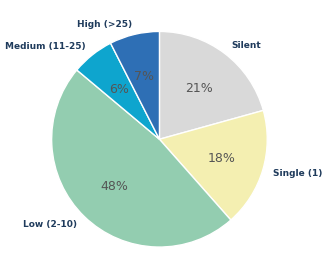

,activity,count
0,Silent,20.7
1,Single (1),17.8
2,Low (2-10),47.6
3,Medium (11-25),6.4
4,High (>25),7.5


In [53]:
## show activity proportion (pie) — reproduces the reference styling on current MS data
order  = ['Silent', 'Single (1)', 'Low (2-10)', 'Medium (11-25)', 'High (>25)']
colors = {'Silent': '#D9D9D9', 'Single (1)': '#F4EFB1', 'Low (2-10)': '#93CDB0',
          'Medium (11-25)': SERAC_C['azure'], 'High (>25)': '#2E6FB5'}
tmp = (MS.groupby('activity').size().reindex(order) / MS.shape[0] * 100.0).to_frame('count')

fig, ax = plt.subplots(figsize=(7, 7), dpi=50)
wedges, texts, autotexts = ax.pie(
    tmp['count'], labels=tmp.index, colors=[colors[a] for a in tmp.index],
    autopct='%.0f%%', startangle=90, counterclock=False,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 13, 'fontweight': 'bold', 'color': '#1f3b5c'})
plt.setp(autotexts, size=18, color='#555555', fontweight='normal')   # % inside slices, grey
ax.set_aspect('equal'); plt.show()
tmp.round(1).reset_index()

## 1. Predictions

#### 1.1. Predicting non-silent compounds (activity > 0)

In [8]:
## Predicting silent compounds on validation set:
ML_data = MS.copy()
ML_data['label'] = (ML_data['ndown'] > 0) * 1

# add features
ML_data = pd.merge(ML_data[['compound','label']],MF_features,on='compound')#.drop_duplicates().reset_index(drop=True)

# predict
# model = RandomForestClassifier(n_estimators=400, class_weight='balanced', n_jobs=16, random_state=0)
model=HistGradientBoostingClassifier(learning_rate=0.03, max_depth=6, max_leaf_nodes=15,l2_regularization=0.0, random_state=42)
trained_model, df_pred = ML_Class.run_K_Fold_Xval_Classification(
    ML_data, ID='compound', model=model, folds=5, col_to_rm=['compound', 'label'],
    v='tqdm', ctf=0.5, impute_by_mean=False)

ML_Class.metrics_from_pred_df(df_pred)

 20%|██        | 1/5 [00:02<00:08,  2.25s/it]

100%|██████████| 5/5 [00:10<00:00,  2.08s/it]


{'roc_auc': 0.6967339923718264, 'pr_auc': 0.8984162361587509}

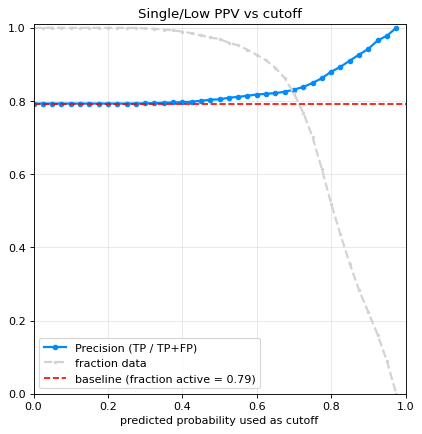

In [9]:
## get PPV from probas
ppv_df = ML_Class.get_PPV_vs_proba(df_pred, npts=40, plot=True,
                                   baseline=df_pred['real_y'].mean(), dpi=80)
plt.title('Single/Low PPV vs cutoff'); plt.show()

In [10]:
## predicting on temporal test sets:
ML_data = MS.copy()
ML_data['label'] = (ML_data['ndown'] > 0) * 1

## define temporal test set:
date_split = '2026-07-14'
test_cmps  = list(MS[MS['date'] >= date_split]['compound'])
print('> number test compounds:',len(test_cmps))
train_cmps = list(ML_data[~ML_data['compound'].isin(test_cmps)]['compound'])

# add features
ML_data = pd.merge(ML_data[['compound','label']],MF_features,on='compound')

# predict the test compounds via a single defined train/test split (unseen-compound eval)
model=HistGradientBoostingClassifier(learning_rate=0.03, max_depth=6, max_leaf_nodes=15,l2_regularization=0.0, random_state=42)
trained_model, df_pred = ML_Class.K_fold_by_defined_IDs_Classification(
    ML_data, ID='compound', ID_sets=[[train_cmps, test_cmps]], model=model,
    col_to_rm=['compound', 'label'], v=False, ctf=0.5, impute_by_mean=False)

auc_m = ML_Class.metrics_from_pred_df(df_pred)['roc_auc']
print(auc_m)

> number test compounds: 316


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:02<00:00,  2.10s/it]

0.6288721804511278


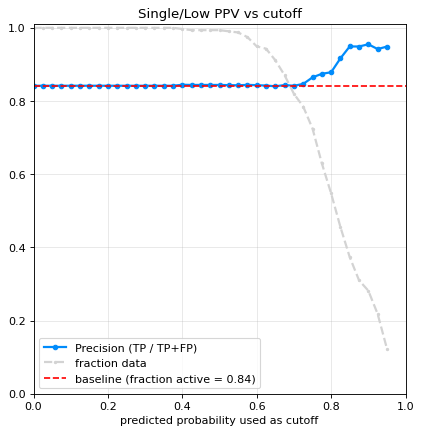

In [11]:
## get PPV from probas
ppv_df = ML_Class.get_PPV_vs_proba(df_pred, npts=40, plot=True,baseline=df_pred['real_y'].mean(), dpi=80)
plt.title('Single/Low PPV vs cutoff'); plt.show()

In [12]:
ppv_df[ppv_df['threshold']>= 0.8]

,threshold,PPV,fraction,n,baseline
32,0.80,0.88,0.55,173,0.84
33,0.82,0.92,0.46,144,0.84
34,0.85,0.95,0.37,118,0.84
35,0.88,0.95,0.31,98,0.84
36,0.90,0.96,0.28,89,0.84
37,0.92,0.94,0.22,69,0.84
38,0.95,0.95,0.12,39,0.84


#### 1.2. Predicting Single-Low by threshold

In [9]:
## find the best label threshold `end` (ndown in [start, end]).
## the label only changes at actual ndown values, so we fit ONCE per distinct cut-point
## (not per integer end) and expand the curve — identical result, ~10x fewer fits.
## HGBC multithreads each fit across all cores, so we run the (few) cut-points sequentially.
SingleLow_ouput = 'output/SingleLow_analysis/range_1_260_singleTask.csv'

if not os.path.exists(SingleLow_ouput):

    start, max_it = 1, 260
    base = pd.merge(MS[['compound', 'ndown']], MF_features, on='compound')
    feat = base.drop(columns='ndown')                 # compound + features (constant across trials)
    cut_ends = [int(e) for e in np.unique(base['ndown']) if start <= e < max_it]
    print(f'> {len(cut_ends)} distinct ndown cut-points to fit (vs {max_it - start} integer ends)')

    fit_at = {}
    for end in tqdm(cut_ends):
        ML_data = feat.copy()
        ML_data['label'] = ((base['ndown'] >= start) & (base['ndown'] <= end)).astype(int).to_numpy()
        model = HistGradientBoostingClassifier(learning_rate=0.03, max_depth=6,
                    max_leaf_nodes=15, l2_regularization=0.0, random_state=42)
        _, df_pred = ML_Class.run_K_Fold_Xval_Classification(
            ML_data, ID='compound', model=model, folds=5, col_to_rm=['compound', 'label'],
            v=False, ctf=0.5, impute_by_mean=False)
        m = ML_Class.metrics_from_pred_df(df_pred)
        fit_at[end] = (m['roc_auc'], m['pr_auc'], int(ML_data['label'].sum()))

    ## expand: every integer end reuses the fit at the largest cut-point <= it (same label -> same AUC)
    results, last = [], (np.nan, np.nan, 0)
    for end in range(start, max_it):
        if end in fit_at: last = fit_at[end]
        results.append([f'{start}_{end}', last[0], last[1], last[2]])

    res_df = pd.DataFrame(results, columns=['range', 'auc', 'pr_auc', 'n'])
    res_df.to_csv(SingleLow_ouput, index=False)

else:
    res_df = pd.read_csv(SingleLow_ouput)

,range,auc,pr_auc,n,xl
0,1_1,0.598317,0.221349,669,1
1,1_2,0.632355,0.416692,1187,2
2,1_3,0.647872,0.536519,1575,3
3,1_4,0.649177,0.608984,1890,4
4,1_5,0.648759,0.643759,2056,5
5,1_6,0.648057,0.678920,2201,6
6,1_7,0.651713,0.707669,2304,7
7,1_8,0.659308,0.725633,2361,8
8,1_9,0.657681,0.743368,2434,9
9,1_10,0.653766,0.752389,2483,10


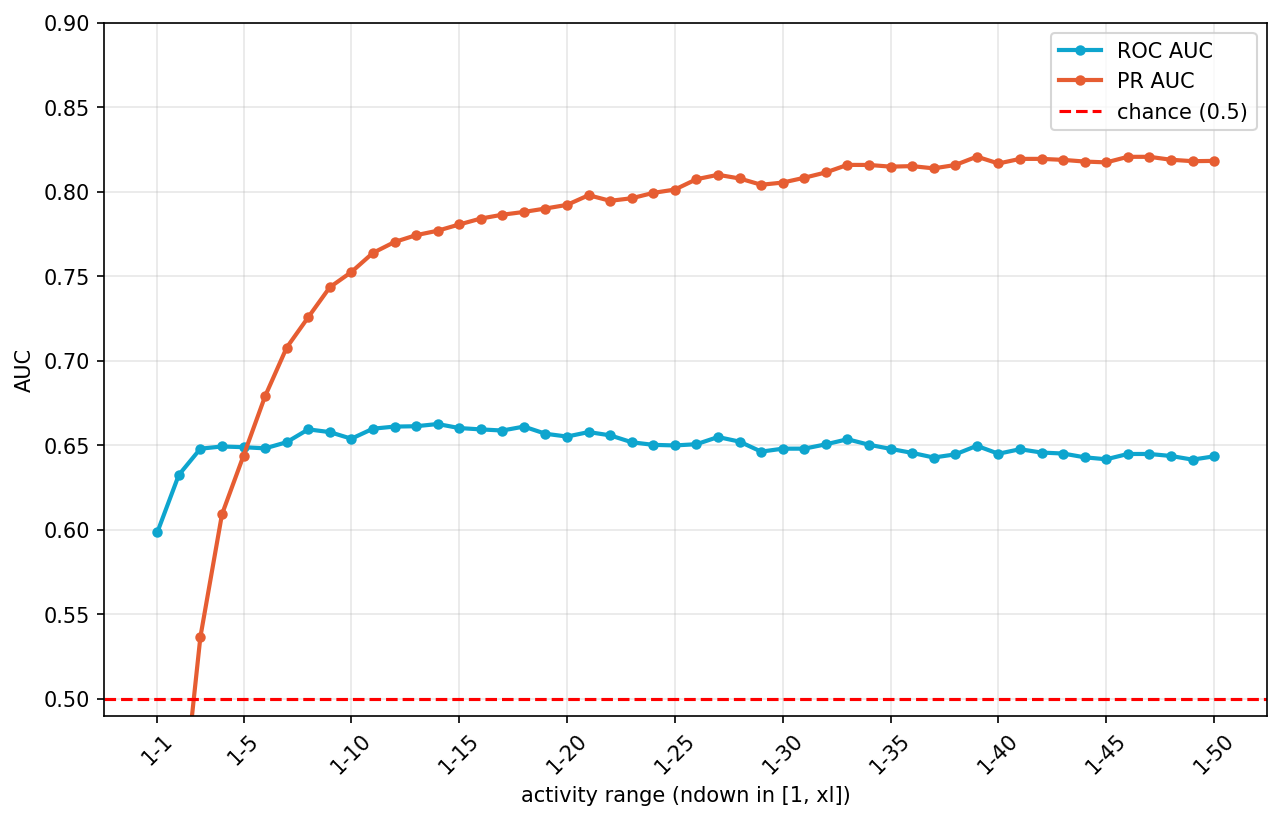

In [10]:
res_df['xl'] = res_df['range'].str.split('_').str[1].astype(int)

# AUC vs upper activity bound (xl), styled like get_PPV_vs_proba
plot_df = res_df[:50]
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
plt.plot('xl', 'auc',    data=plot_df, color=SERAC_C['azure'], linewidth=2, marker='o', markersize=4, label='ROC AUC')
plt.plot('xl', 'pr_auc', data=plot_df, color=SERAC_C['ember'], linewidth=2, marker='o', markersize=4, label='PR AUC')
plt.axhline(0.5, color='r', linestyle='--', linewidth=1.5, label='chance (0.5)')

# x-ticks as ranges every 5: 1-1, 1-5, 1-10, 1-15, ...
ticks = [1] + list(range(5, int(plot_df['xl'].max()) + 1, 5))
ax.set_xticks(ticks); ax.set_xticklabels([f'1-{t}' for t in ticks], rotation=45)
plt.legend(); plt.xlabel('activity range (ndown in [1, xl])'); plt.ylabel('AUC')
plt.ylim(0.49, 0.9); plt.grid(axis='both', alpha=0.3)

res_df.head(20)

In [11]:
res_df.loc[res_df.range.isin(['1_8','1_12']), 'n']

7     2361
11    2544
Name: n, dtype: int64

In [30]:
## build activity classifier:
ML_data = MS.copy()
ML_data['label'] = ML_data['ndown'].apply(lambda x: (x >= 1 and x <= 12 ) * 1)
ML_data = ML_data[ML_data['date'] <= '2026-07-06'] # 
print(ML_data.shape)

# add features
ML_data = pd.merge(ML_data[['compound','label']],MF_features,on='compound')#.drop_duplicates().reset_index(drop=True)

# predict
# model = RandomForestClassifier(n_estimators=400, class_weight='balanced', n_jobs=16, random_state=0)
model=HistGradientBoostingClassifier(learning_rate=0.03, max_depth=6, max_leaf_nodes=15,l2_regularization=0.0, random_state=42)
trained_model, df_pred = ML_Class.run_K_Fold_Xval_Classification(
    ML_data, ID='compound', model=model, folds=5, col_to_rm=['compound', 'label'],
    v='tqdm', ctf=0.5, impute_by_mean=False)
print('classification roc_auc:', round(ML_Class.metrics_from_pred_df(df_pred)['roc_auc'], 3))

# ## ICP (inductive conformal prediction): same CV, adds per-compound class p-values (p_1/p_2) + credibility (cred)
# icp_model, icp_pred = ML_Class.run_K_Fold_Xval_CP(
#     ML_data, ID='compound', model=model, folds=5, col_to_rm=['compound', 'label'],
#     v=False, ctf=0.5, impute=False)
# print('ICP roc_auc:', round(ML_Class.metrics_from_pred_df(icp_pred)['roc_auc'], 3))
# icp_pred.head()

(3821, 6)


100%|██████████| 5/5 [00:09<00:00,  1.98s/it]

classification roc_auc: 0.656


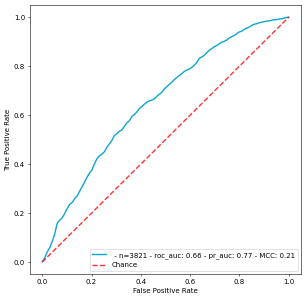

In [31]:
tmp = ML_Class.plot_roc_curve([df_pred],c=[SERAC_C['azure']],dpi=50)

In [32]:
# cred_ctf = 0.4
# low_cred  = icp_pred[icp_pred['cred'] <  cred_ctf]
# high_cred = icp_pred[icp_pred['cred'] >= cred_ctf]
# # overlay the original (non-ICP) classifier ROC alongside the two credibility-split ICP curves
# tmp = ML_Class.plot_roc_curve(
#     [df_pred, low_cred, high_cred],
#     l=['all (no ICP)', 'cred < %.2f' % cred_ctf, 'cred >= %.2f' % cred_ctf],
# )

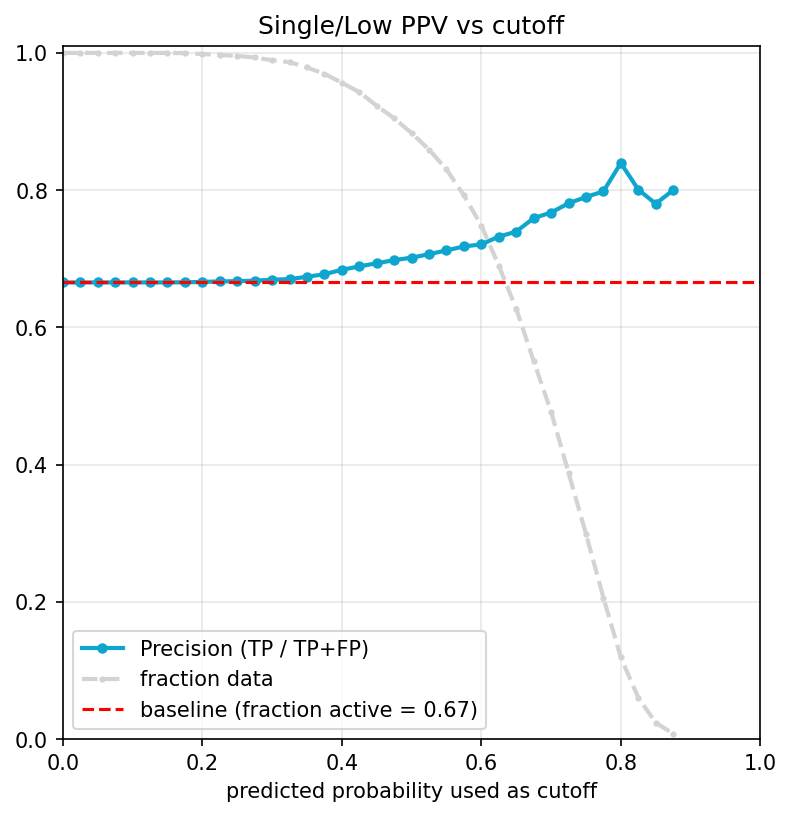

,threshold,PPV,fraction,n,baseline,enrichment
30,0.75,0.79,0.30,1143,0.67,1.19
31,0.78,0.80,0.21,788,0.67,1.20
32,0.80,0.84,0.12,455,0.67,1.26
33,0.82,0.80,0.06,231,0.67,1.20
34,0.85,0.78,0.02,91,0.67,1.17
35,0.88,0.80,0.01,30,0.67,1.20


In [33]:
## get PPV from probas
ppv_df = ML_Class.get_PPV_vs_proba(df_pred, npts=40, plot=True,baseline=df_pred['real_y'].mean(), dpi=150,min_n=20,color=SERAC_C['azure'])
plt.title('Single/Low PPV vs cutoff'); plt.show()
ppv_df[ppv_df['threshold']>=0.75]

In [ ]:
print(MS['date'].unique())

<DatetimeArray>
['2026-04-29 00:00:00', '2026-05-20 00:00:00', '2026-05-29 00:00:00',
 '2026-06-16 00:00:00', '2026-06-17 00:00:00', '2026-06-23 00:00:00',
 '2026-06-30 00:00:00', '2026-07-06 00:00:00', '2026-07-14 00:00:00']
Length: 9, dtype: datetime64[us]


In [60]:
## predicting on temporal test sets:
ML_data = MS.copy()
ML_data['label'] = ML_data['ndown'].apply(lambda x: (x >= 1 and x <= 12 ) * 1)

## define temporal test set:
date_split = '2026-07-14' # '2026-07-06' # '2026-05-20' #  # '2026-07-14' #       
test_cmps  = list(MS[MS['date'] >= date_split]['compound'])
print('> number test compounds:',len(test_cmps))
train_cmps = list(ML_data[~ML_data['compound'].isin(test_cmps)]['compound'])

## make sure no data leakage between train and test
assert stats_tools.intersection(test_cmps,train_cmps) == []

# add features
ML_data = pd.merge(ML_data[['compound','label']],MF_features,on='compound')

# predict the test compounds via a single defined train/test split (unseen-compound eval)
# model = RandomForestClassifier(n_estimators=400, class_weight='balanced', n_jobs=16, random_state=0)
model=HistGradientBoostingClassifier(learning_rate=0.03, max_depth=6, max_leaf_nodes=15,l2_regularization=0.0, random_state=42)
trained_model, df_pred_test = ML_Class.K_fold_by_defined_IDs_Classification(
    ML_data, ID='compound', ID_sets=[[train_cmps, test_cmps]], model=model,
    col_to_rm=['compound', 'label'], v=False, ctf=0.5, impute_by_mean=False)

ML_Class.metrics_from_pred_df(df_pred_test)

> number test compounds: 316


100%|██████████| 1/1 [00:02<00:00,  2.12s/it]


{'roc_auc': 0.6351112234580384, 'pr_auc': 0.8141627491470598}

[]

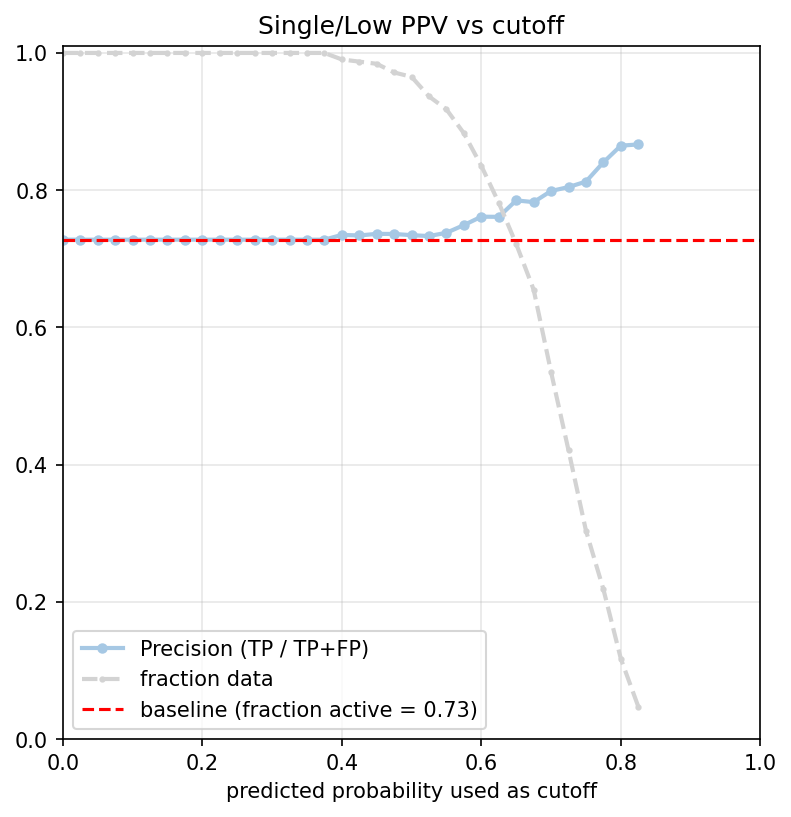

In [56]:
## get PPV from probas
ppv_df = ML_Class.get_PPV_vs_proba(df_pred_test, npts=40, plot=True,baseline=df_pred_test['real_y'].mean(), dpi=150,min_n=11,color=SERAC_C['sky_blue'])
plt.title('Single/Low PPV vs cutoff'); plt.show()

In [57]:
ppv_df[ppv_df['threshold']>=0.75]

,threshold,PPV,fraction,n,baseline,enrichment
30,0.75,0.81,0.30,96,0.73,1.12
31,0.78,0.84,0.22,69,0.73,1.15
32,0.80,0.86,0.12,37,0.73,1.19
33,0.82,0.87,0.05,15,0.73,1.19


In [24]:
## save/update model to MLTrail:
## deployable binary classifier — "active" = ndown in [1, 12] vs rest, whole library, H236 features.
## MLTrail featurizes new SMILES with its built-in H236 featurizer (vendored bit-for-bit from
## compute_H236_features) and aligns to the saved feature_cols.

# label = activity in [1, 12]; features = the H236 universe already in MF_features
ML_data = MS.copy()
ML_data['label'] = ((ML_data['ndown'] >= 1) & (ML_data['ndown'] <= 12)).astype(int)
ML_data = pd.merge(ML_data[['compound', 'label']], MF_features, on='compound')
feat_cols = [c for c in ML_data.columns if c not in ('compound', 'label')]
print(f'> ML_data: {len(ML_data):,} rows | features={len(feat_cols):,}')
print(ML_data['label'].value_counts().to_string())

clf = HistGradientBoostingClassifier(learning_rate=0.03, max_depth=6, max_leaf_nodes=15,
                                     l2_regularization=0.0, random_state=42)

# CV metrics for the registry (same 5-fold as the classifier cell above)
_, cv_pred = ML_Class.run_K_Fold_Xval_Classification(
    ML_data, ID='compound', model=clf, folds=5, col_to_rm=['compound', 'label'],
    v=False, ctf=0.5, impute_by_mean=False)
cv = ML_Class.metrics_from_pred_df(cv_pred)
print(f"> CV roc_auc={cv['roc_auc']:.3f}  pr_auc={cv['pr_auc']:.3f}")

# fit on the whole library and hand the {model, feature_cols} bundle straight to MLTrail
# (it joblib-dumps the bundle into the vault as <id>_v<ver>.joblib — no separate local copy needed)
clf.fit(ML_data[feat_cols], ML_data['label'])
bundle = {'model': clf, 'feature_cols': feat_cols, 'task': 'activity_1_12_binary',
          'positive': 'ndown in [1,12]', 'features': 'H236', 'n_train': len(ML_data),
          'class_counts': ML_data['label'].value_counts().to_dict(),
          'sklearn_ver': __import__('sklearn').__version__}

# training set to archive alongside the model — MLTrail keeps only compound/smiles/label
# (features are reconstructible from smiles via the H236 featurizer), stored as delta parquet
train_set = ML_data[['compound', 'label']].merge(
    serac_df[['compound', 'smiles']].drop_duplicates('compound'), on='compound')

# if a model with this name already exists, add a new version to its id (keeps history);
# otherwise register a fresh entry. avoids spawning duplicate ids on re-run.
name = 'Px_activity_1_12'
hit  = registry.list().pipe(lambda d: d.loc[d['experiment_name'] == name, 'id'])
model_id = int(hit.iloc[0]) if len(hit) else None   # existing id -> new version; None -> new entry

model_id = registry.add(model_id=model_id,
                        experiment_name=name, experiment_measure='proteomics_activity',
                        unit='n_proteins_down', model_type='single_task_classification',
                        framework='sklearn', features_type='H236',
                        model=bundle,
                        training_set=train_set, smiles_column='smiles',
                        compound_id_column='compound', label_column='label',
                        metrics={'roc_auc': round(cv['roc_auc'], 3), 'pr_auc': round(cv['pr_auc'], 3)})
print(f"> {'updated (new version of)' if len(hit) else 'registered'} MLTrail model id={model_id}  "
      f'({len(train_set):,} training rows archived)')
registry.list()

> ML_data: 4,137 rows | features=2,558
label
1    2773
0    1364
> CV roc_auc=0.656  pr_auc=0.771
> updated (new version of) MLTrail model id=1  (4,137 training rows archived)


,id,date,experiment_name,experiment_measure
0,1,20260716_032151,Px_activity_1_12,proteomics_activity
1,4,20260714_053505,Px_activity_not_high_20,proteomics_activity


In [25]:
## check model details:
for k, v in registry.details(model_id).items():
    print(f'{k:20s}: {v}')

id                  : 1
experiment_name     : Px_activity_1_12
experiment_measure  : proteomics_activity
unit                : n_proteins_down
model_type          : single_task_classification
framework           : sklearn
features_type       : H236
training_set_dir    : /data2/MLTrail_vault/training_sets/1
model_path          : /data2/MLTrail_vault/models/1_v2.joblib
metrics             : {'roc_auc': 0.656, 'pr_auc': 0.771}
version             : 2
date                : 20260716_032151


In [23]:
registry.list()

,id,date,experiment_name,experiment_measure
0,1,20260714_044404,Px_activity_1_12,proteomics_activity
1,4,20260714_053505,Px_activity_not_high_20,proteomics_activity


#### 1.3. Predicting High activity:

In [32]:
## find the best threshold to identify HIGH activity compounds:
## open-ended positive class = high degraders ndown >= start (no upper ceiling); sweep the
## threshold `start` UP from `floor` (~20). the label only changes at actual ndown values,
## so we fit ONCE per distinct cut-point >= floor and expand the curve — identical, fewer fits.
High_ouput = 'output/SingleLow_analysis/notHigh_start_1_singleTask.csv'

if not os.path.exists(High_ouput):

    floor = 1
    base  = pd.merge(MS[['compound', 'ndown']], MF_features, on='compound')
    feat  = base.drop(columns='ndown')                 # compound + features (constant across trials)
    hi    = int(base['ndown'].max())
    cut_starts = [int(v) for v in np.unique(base['ndown']) if v >= floor]
    print(f'> {len(cut_starts)} distinct ndown cut-points to fit (threshold from {floor} to {hi})')

    fit_at = {}
    for start in tqdm(cut_starts):
        ML_data = feat.copy()
        ML_data['label'] = (base['ndown'] <= start).astype(int).to_numpy()
        model = HistGradientBoostingClassifier(learning_rate=0.03, max_depth=6,
                    max_leaf_nodes=15, l2_regularization=0.0, random_state=42)
        _, df_pred = ML_Class.run_K_Fold_Xval_Classification(
            ML_data, ID='compound', model=model, folds=5, col_to_rm=['compound', 'label'],
            v=False, ctf=0.5, impute_by_mean=False)
        m = ML_Class.metrics_from_pred_df(df_pred)
        fit_at[start] = (m['roc_auc'], m['pr_auc'], int(ML_data['label'].sum()))

    ## expand: every integer threshold reuses the fit at the smallest cut-point >= it (same label -> same AUC)
    cut_arr = np.array(sorted(fit_at))
    results = []
    for start in range(floor, hi + 1):
        ge = cut_arr[cut_arr >= start]
        auc, pr_auc, n = fit_at[int(ge[0])] if len(ge) else (np.nan, np.nan, 0)
        results.append([f'>={start}', auc, pr_auc, n])

    res_df = pd.DataFrame(results, columns=['range', 'auc', 'pr_auc', 'n'])
    res_df.to_csv(High_ouput, index=False)

else:
    res_df = pd.read_csv(High_ouput)

> 185 distinct ndown cut-points to fit (threshold from 1 to 1940)


100%|██████████| 185/185 [29:36<00:00,  9.60s/it]


In [35]:
res_df

,range,auc,pr_auc,n
0,>=1,0.695640,0.560097,1591
1,>=2,0.696514,0.677361,2149
2,>=3,0.704682,0.759746,2574
3,>=4,0.738975,0.836448,2925
4,>=5,0.748744,0.873169,3112
...,...,...,...,...
1935,>=1936,NaN,1.000000,4137
1936,>=1937,NaN,1.000000,4137
1937,>=1938,NaN,1.000000,4137
1938,>=1939,NaN,1.000000,4137


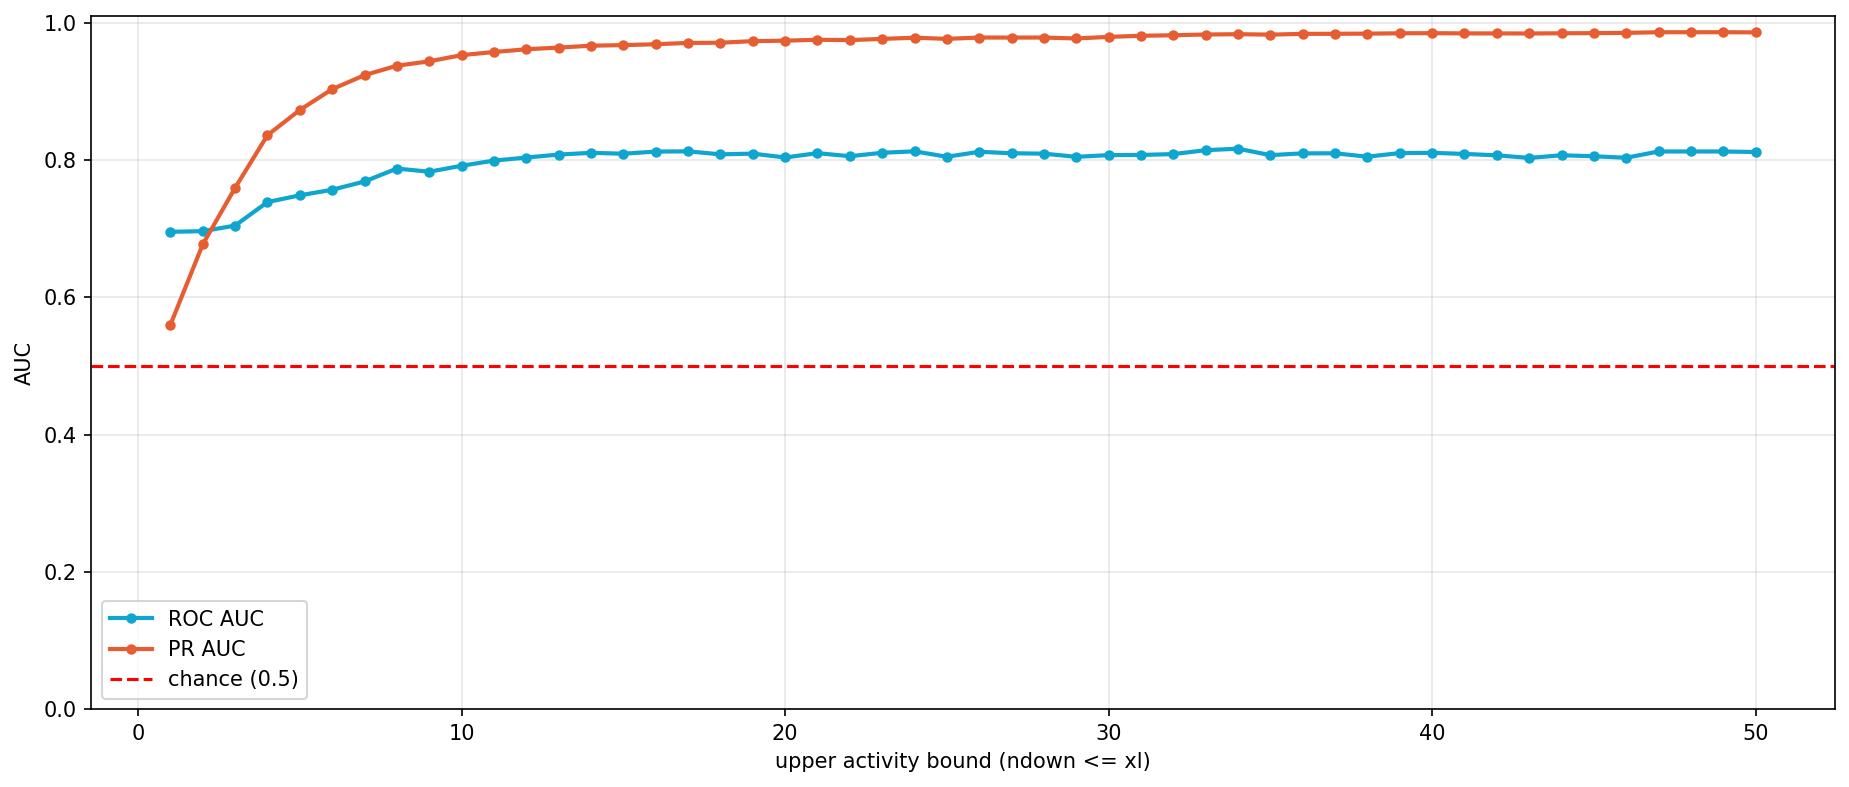

In [45]:
res_df['xl'] = res_df['range'].str.replace('>=','').astype(int)

# AUC vs upper activity bound (xl), styled like get_PPV_vs_proba
fig, ax = plt.subplots(figsize=(15, 6), dpi=150)
plt.plot('xl', 'auc',    data=res_df[:50], color=SERAC_C['azure'], linewidth=2, marker='o', markersize=4, label='ROC AUC')
plt.plot('xl', 'pr_auc', data=res_df[:50], color=SERAC_C['ember'], linewidth=2, marker='o', markersize=4, label='PR AUC')
plt.axhline(0.5, color='r', linestyle='--', linewidth=1.5, label='chance (0.5)')
plt.legend(); plt.xlabel('upper activity bound (ndown <= xl)'); plt.ylabel('AUC')
plt.ylim(0.0, 1.01); plt.grid(axis='both', alpha=0.3)

In [34]:
# res_df[res_df['pr_auc']==res_df['pr_auc'].max()]

In [18]:
## build activity classifier:
ML_data = MS.copy()
ML_data['label'] = ML_data['ndown'].apply(lambda x: ( x <= 20 ) * 1)

# add features
ML_data = pd.merge(ML_data[['compound','label']],MF_features,on='compound')#.drop_duplicates().reset_index(drop=True)

# predict
# model = RandomForestClassifier(n_estimators=400, class_weight='balanced', n_jobs=16, random_state=0)
model=HistGradientBoostingClassifier(learning_rate=0.03, max_depth=6, max_leaf_nodes=15,l2_regularization=0.0, random_state=42)
trained_model, df_pred = ML_Class.run_K_Fold_Xval_Classification(
    ML_data, ID='compound', model=model, folds=5, col_to_rm=['compound', 'label'],
    v='tqdm', ctf=0.5, impute_by_mean=False)
ML_Class.metrics_from_pred_df(df_pred)

100%|██████████| 5/5 [00:10<00:00,  2.02s/it]


{'roc_auc': 0.8039064145127399, 'pr_auc': 0.9741438826507202}

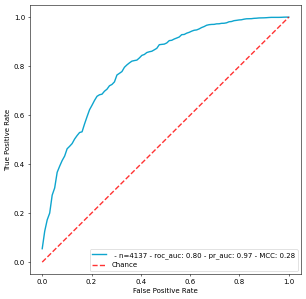

In [28]:
tmp = ML_Class.plot_roc_curve([df_pred],c=[SERAC_C['azure']],dpi=50)

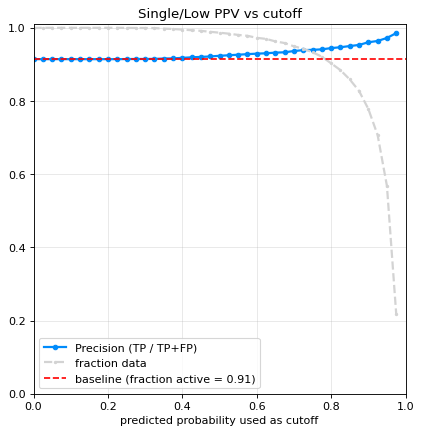

In [19]:
## get PPV from probas
ppv_df = ML_Class.get_PPV_vs_proba(df_pred, npts=40, plot=True,baseline=df_pred['real_y'].mean(), dpi=80)
plt.title('Single/Low PPV vs cutoff'); plt.show()

In [ ]:
## predicting on temporal test sets:
ML_data = MS.copy()
ML_data['label'] = ML_data['ndown'].apply(lambda x: (x <=20 ) * 1)

## define temporal test set:
date_split = '2026-07-06'
test_cmps  = list(MS[MS['date'] >= date_split]['compound'])
print('> number test compounds:',len(test_cmps))
train_cmps = list(ML_data[~ML_data['compound'].isin(test_cmps)]['compound'])

# add features
ML_data = pd.merge(ML_data[['compound','label']],MF_features,on='compound')

# predict the test compounds via a single defined train/test split (unseen-compound eval)
# model = RandomForestClassifier(n_estimators=400, class_weight='balanced', n_jobs=16, random_state=0)
model=HistGradientBoostingClassifier(learning_rate=0.03, max_depth=6, max_leaf_nodes=15,l2_regularization=0.0, random_state=42)
trained_model, df_pred_test = ML_Class.K_fold_by_defined_IDs_Classification(
    ML_data, ID='compound', ID_sets=[[train_cmps, test_cmps]], model=model,
    col_to_rm=['compound', 'label'], v=False, ctf=0.5, impute_by_mean=False)

ML_Class.metrics_from_pred_df(df_pred_test)

In [ ]:
## get PPV from probas
ppv_df = ML_Class.get_PPV_vs_proba(df_pred_test, npts=40, plot=True,baseline=df_pred_test['real_y'].mean(), dpi=80)
plt.title('Single/Low PPV vs cutoff'); plt.show()

In [ ]:
## save High model to MLTrail:
## deployable binary classifier — "high activity" = ndown >= 20 vs rest, whole library, H236 features.
## MLTrail featurizes new SMILES with its built-in H236 featurizer (vendored bit-for-bit from
## compute_H236_features) and aligns to the saved feature_cols.

# label = high activity (ndown <= 20); features = the H236 universe already in MF_features
ML_data = MS.copy()
ML_data['label'] = (ML_data['ndown'] <= 20).astype(int)
ML_data = pd.merge(ML_data[['compound', 'label']], MF_features, on='compound')
feat_cols = [c for c in ML_data.columns if c not in ('compound', 'label')]
print(f'> ML_data: {len(ML_data):,} rows | features={len(feat_cols):,}')
print(ML_data['label'].value_counts().to_string())

clf = HistGradientBoostingClassifier(learning_rate=0.03, max_depth=6, max_leaf_nodes=15,
                                     l2_regularization=0.0, random_state=42)

# CV metrics for the registry
_, cv_pred = ML_Class.run_K_Fold_Xval_Classification(
    ML_data, ID='compound', model=clf, folds=5, col_to_rm=['compound', 'label'],
    v=False, ctf=0.5, impute_by_mean=False)
cv = ML_Class.metrics_from_pred_df(cv_pred)
print(f"> CV roc_auc={cv['roc_auc']:.3f}  pr_auc={cv['pr_auc']:.3f}")

# fit on the whole library and hand the {model, feature_cols} bundle straight to MLTrail
clf.fit(ML_data[feat_cols], ML_data['label'])
bundle = {'model': clf, 'feature_cols': feat_cols, 'task': 'activity_high_binary',
          'positive': 'ndown >= 20', 'features': 'H236', 'n_train': len(ML_data),
          'class_counts': ML_data['label'].value_counts().to_dict(),
          'sklearn_ver': __import__('sklearn').__version__}

# training set to archive alongside the model (compound/smiles/label only)
train_set = ML_data[['compound', 'label']].merge(
    serac_df[['compound', 'smiles']].drop_duplicates('compound'), on='compound')

# `registry` is configured once in the params cell; re-running adds a new version
# (pass model_id=<id> to version an existing entry instead)
model_id = registry.add(experiment_name='Px_activity_not_high_20', experiment_measure='proteomics_activity',
                        unit='n_proteins_down', model_type='single_task_classification',
                        framework='sklearn', features_type='H236',
                        model=bundle,
                        training_set=train_set, smiles_column='smiles',
                        compound_id_column='compound', label_column='label',
                        metrics={'roc_auc': round(cv['roc_auc'], 3), 'pr_auc': round(cv['pr_auc'], 3)})
print(f'> registered in MLTrail: id={model_id}  ({len(train_set):,} training rows archived)')
registry.list()

#### 1.4. Using both models at the same time to prioritize compounds:

In [35]:
## final test: predicting on temporal test set Not Silent and Not high
ML_data = MS.copy()
ML_data['label_nothigh'] = (ML_data['ndown'] <= 12).astype(int)   # non-high = ndown <= 20 (incl. silent)
ML_data['label_notsilent']     = (ML_data['ndown'] >= 1 ).astype(int)

## define temporal test set:
date_split = '2026-07-06'
test_cmps  = list(MS[MS['date'] >= date_split]['compound'])
print('> number test compounds:', len(test_cmps))
train_cmps = list(ML_data[~ML_data['compound'].isin(test_cmps)]['compound'])

# add features
ML_data = pd.merge(ML_data[['compound', 'label_nothigh', 'label_notsilent']], MF_features, on='compound')

# the helper reads a single 'label' col, so predict each task on the SAME temporal split, then
# stitch the two proba columns together (both runs score the same test rows in the same order)
model = HistGradientBoostingClassifier(learning_rate=0.03, max_depth=6, max_leaf_nodes=15,
                                       l2_regularization=0.0, random_state=42)
preds = {}
for task in ['nothigh', 'notsilent']:
    _, preds[task] = ML_Class.K_fold_by_defined_IDs_Classification(
        ML_data.assign(label=ML_data[f'label_{task}']), ID='compound', ID_sets=[[train_cmps, test_cmps]],
        model=model, col_to_rm=['compound', 'label', 'label_nothigh', 'label_notsilent'],
        v=False, ctf=0.5, impute_by_mean=False)

assert (preds['nothigh']['compound'].values == preds['notsilent']['compound'].values).all()
df_pred_test = pd.DataFrame({'compound':      preds['nothigh']['compound'].values,
                             'real_nothigh':  preds['nothigh']['real_y'].values,
                             'proba_nothigh': preds['nothigh']['probas'].values,
                             'real_notsilent':      preds['notsilent']['real_y'].values,
                             'proba_notsilent':     preds['notsilent']['probas'].values})

# temporal (unseen-compound) AUC per task; 'n/a' if the test set has only one class for that task
for task in ['nothigh', 'notsilent']:
    r, p = df_pred_test[f'real_{task}'], df_pred_test[f'proba_{task}']
    auc = f"{ML_Class.compute_ROC_AUC(r, p):.3f}" if r.nunique() > 1 else 'n/a (one class in test)'
    print(f"> {task:7s} test roc_auc = {auc}  ({int(r.sum())} positives / {len(r)})")
df_pred_test.head()

> number test compounds: 677


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:01<00:00,  1.63s/it]

> nothigh test roc_auc = 0.910  (603 positives / 677)
> notsilent test roc_auc = 0.632  (552 positives / 677)


,compound,real_nothigh,proba_nothigh,real_notsilent,proba_notsilent
0,SRB-0006317,0,0.901138,1,0.933340
1,SRB-0010965,1,0.769543,1,0.931229
2,SRB-0010799,0,0.565741,1,0.963540
3,SRB-0010995,0,0.677618,1,0.958041
4,SRB-0009670,0,0.604879,1,0.927890


In [37]:
## combine the 2 models to bracket the active band [1,12]:
##   predicted discreet = predicted not-silent (ndown>=1) AND predicted not-high (ndown<=12)
## then ask: of those PREDICTED discreet, how many are REALLY in [1,12]? (precision of the joint call)
ctf = 0.8
df_pred_test['pred_discreet'] = ((df_pred_test['proba_notsilent'] >= 0.85) &
                                 (df_pred_test['proba_nothigh']   >= 0.9)).astype(int)
# ground truth: really in [1,12] = really not-silent AND really not-high
df_pred_test['real_discreet'] = ((df_pred_test['real_notsilent'] == 1) &
                                 (df_pred_test['real_nothigh']   == 1)).astype(int)

sel = df_pred_test[df_pred_test['pred_discreet'] == 1]
print(f'> predicted discreet (both models, ctf={ctf}): {len(sel)} / {len(df_pred_test)} compounds')
print(f'> of those, really in [1,12] ndown: {int(sel["real_discreet"].sum())} '
      f'({sel["real_discreet"].mean():.1%} precision)')
df_pred_test.head()

> predicted discreet (both models, ctf=0.8): 125 / 677 compounds
> of those, really in [1,12] ndown: 101 (80.8% precision)


,compound,real_nothigh,proba_nothigh,real_notsilent,proba_notsilent,pred_discreet,real_discreet
0,SRB-0006317,0,0.901138,1,0.933340,1,0
1,SRB-0010965,1,0.769543,1,0.931229,0,1
2,SRB-0010799,0,0.565741,1,0.963540,0,0
3,SRB-0010995,0,0.677618,1,0.958041,0,0
4,SRB-0009670,0,0.604879,1,0.927890,0,0


In [33]:
## final test: predicting on temporal test set discreet
## predicting on temporal test sets:
ML_data = MS.copy()
ML_data['label'] = ML_data['ndown'].apply(lambda x: (x >= 1 and x <= 12 ) * 1)

## define temporal test set:
date_split = '2026-07-06' # '2026-07-14' # 
test_cmps  = list(MS[MS['date'] >= date_split]['compound'])
print('> number test compounds:',len(test_cmps))
train_cmps = list(ML_data[~ML_data['compound'].isin(test_cmps)]['compound'])

# add features
ML_data = pd.merge(ML_data[['compound','label']],MF_features,on='compound')

# predict the test compounds via a single defined train/test split (unseen-compound eval)
# model = RandomForestClassifier(n_estimators=400, class_weight='balanced', n_jobs=16, random_state=0)
model=HistGradientBoostingClassifier(learning_rate=0.03, max_depth=6, max_leaf_nodes=15,l2_regularization=0.0, random_state=42)
trained_model, df_pred_test = ML_Class.K_fold_by_defined_IDs_Classification(
    ML_data, ID='compound', ID_sets=[[train_cmps, test_cmps]], model=model,
    col_to_rm=['compound', 'label'], v=False, ctf=0.5, impute_by_mean=False)

m = ML_Class.metrics_from_pred_df(df_pred_test)
print(f"> single-model roc_auc={m['roc_auc']:.3f}  pr_auc={m['pr_auc']:.3f}")

# apple-to-apple with the 2-model approach: precision of "predicted in [1,12]" at the SAME ctf=0.5,
# SAME test compounds, SAME ground truth (real_y = ndown in [1,12] == real_discreet in the 2-model cell)
sel = df_pred_test[df_pred_test['probas'] >= 0.8]
print(f'> predicted discreet (proba>=0.5): {len(sel)} / {len(df_pred_test)} compounds')
print(f"> of those, really in [1,12] ndown: {int(sel['real_y'].sum())} ({sel['real_y'].mean():.1%} precision)")

> number test compounds: 677


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:02<00:00,  2.10s/it]

> single-model roc_auc=0.630  pr_auc=0.772
> predicted discreet (proba>=0.5): 121 / 677 compounds
> of those, really in [1,12] ndown: 100 (82.6% precision)


In [ ]:
low_only = df_pred_test[ (df_pred_test['proba_low'] > 0.8) ].copy()
low_only['real_low'].sum() / low_only.shape[0]

In [ ]:
high_only = df_pred_test[(df_pred_test['proba_nothigh'] > 0.8) & (df_pred_test['proba_low'] > 0.8) ]
high_only['real_low'].sum() / high_only.shape[0]

In [ ]:
## ensure the MLTrail model predicts as intended:
## score the TEMPORAL TEST compounds (same split as above) with the DEPLOYED low (1-12) model
## and compare to the true labels. NB: these compounds were in the model's training set (fit on
## the whole library), so this is an IN-SAMPLE plumbing check — not the unseen-compound eval that
## cell 1.4's K-fold split gives. Expect strong agreement if the deploy path is correct.
date_split = '2026-07-06'
test_df = (MS[MS['date'] >= date_split][['compound', 'ndown']].drop_duplicates('compound')
             .merge(serac_df[['compound', 'smiles']].drop_duplicates('compound'), on='compound')
             .reset_index(drop=True))
test_df['real_low'] = ((test_df['ndown'] >= 1) & (test_df['ndown'] <= 12)).astype(int)

# registry.predict takes an in-memory DataFrame directly; it re-derives H236 from the SMILES
low_id = registry.list().set_index('experiment_name').loc['Px_activity_1_12', 'id']
pred = registry.predict(low_id, test_df, smiles_column='smiles', compound_id='compound')

mlt_pred = test_df.copy()
mlt_pred['proba_low'] = pred['probability'].values   # P(positive class)
mlt_pred['pred_low']  = pred['prediction'].values     # hard label at ctf=0.5

# agreement vs the true labels (in-sample -> should be strong if the model/deploy path is sound)
r, prob, pred_y = mlt_pred['real_low'], mlt_pred['proba_low'], mlt_pred['pred_low']
auc = f'{ML_Class.compute_ROC_AUC(r, prob):.3f}' if r.nunique() > 1 else 'n/a (one class)'
print(f'> scored {len(mlt_pred):,} temporal-test compounds through the low (1-12) MLTrail model')
print(f'  roc_auc={auc}  acc={(pred_y == r).mean():.3f}  ({int(r.sum())} positives / {len(r)})')
mlt_pred.head()

In [ ]:
final = mlt_pred[mlt_pred['proba_low']>0.80]
final['real_low'].sum() / final.shape[0]